In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load both datasets
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches dataset:", matches.shape)
print("Deliveries dataset:", deliveries.shape)
matches.head()

Matches dataset: (1095, 20)
Deliveries dataset: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
# Understand the data
print("Seasons covered:", sorted(matches['season'].unique()))
print("Total matches:", len(matches))
print("Teams:", matches['team1'].nunique())
print("Venues:", matches['venue'].nunique())
print("Missing values:")
print(matches.isnull().sum())

Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total matches: 1095
Teams: 19
Venues: 58
Missing values:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


Overall: Toss winners win the match 50.6% of the time

Win rate by toss decision:
toss_decision
bat      45.3
field    53.6
Name: toss_match_winner, dtype: float64


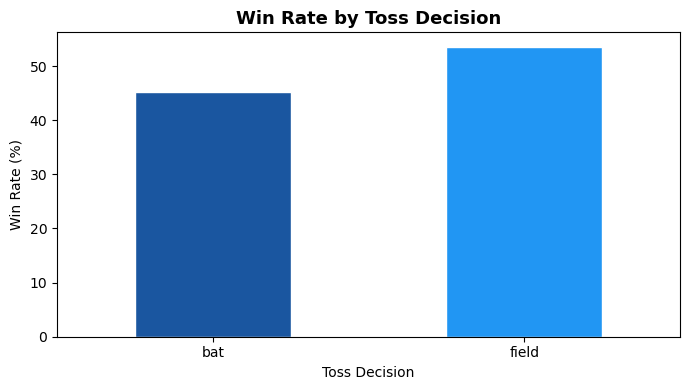

In [5]:
# Did winning the toss help win the match?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
toss_win_rate = matches['toss_match_winner'].mean() * 100
print(f"Overall: Toss winners win the match {toss_win_rate:.1f}% of the time")

# Toss decision breakdown
toss_decision = matches.groupby('toss_decision')['toss_match_winner'].mean() * 100
print("\nWin rate by toss decision:")
print(toss_decision.round(1))

# Chart
plt.figure(figsize=(7,4))
toss_decision.plot(kind='bar', color=['#1A56A0','#2196F3'], edgecolor='white')
plt.title('Win Rate by Toss Decision', fontweight='bold', fontsize=13)
plt.ylabel('Win Rate (%)')
plt.xlabel('Toss Decision')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top teams by win rate %:
Chennai Super Kings            58.0
Mumbai Indians                 55.2
Delhi Capitals                 52.7
Kolkata Knight Riders          52.2
Rajasthan Royals               50.7
Sunrisers Hyderabad            48.4
Royal Challengers Bangalore    48.3
Kings XI Punjab                46.3
Name: count, dtype: float64


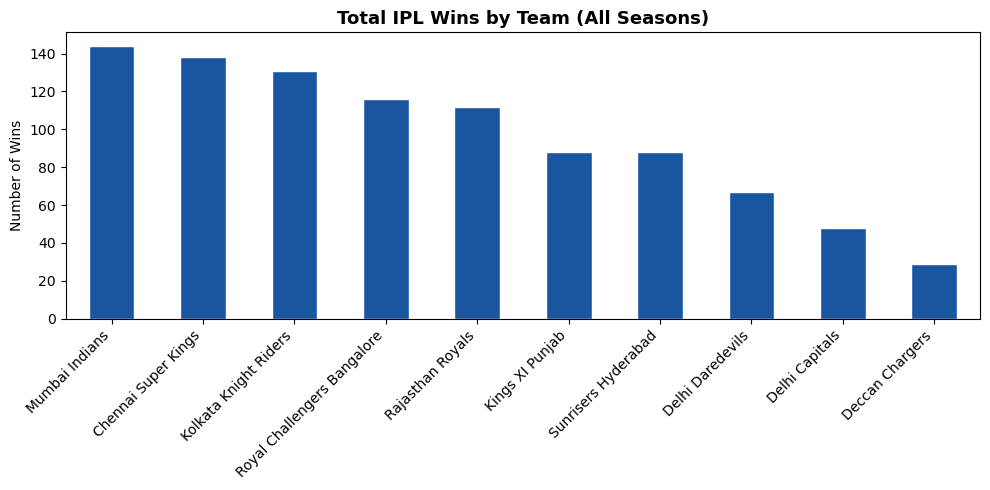

In [6]:
# Total wins per team
team_wins = matches['winner'].value_counts().head(10)

# Win rate (wins / total matches played)
team1 = matches['team1'].value_counts()
team2 = matches['team2'].value_counts()
total_played = (team1 + team2).fillna(0)
win_rate = (team_wins / total_played * 100).dropna().sort_values(ascending=False).head(8)

print("Top teams by win rate %:")
print(win_rate.round(1))

# Chart
plt.figure(figsize=(10,5))
team_wins.plot(kind='bar', color='#1A56A0', edgecolor='white')
plt.title('Total IPL Wins by Team (All Seasons)', fontweight='bold', fontsize=13)
plt.ylabel('Number of Wins')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Batting first win rate: 45.3%
Chasing (field first) win rate: 53.6%


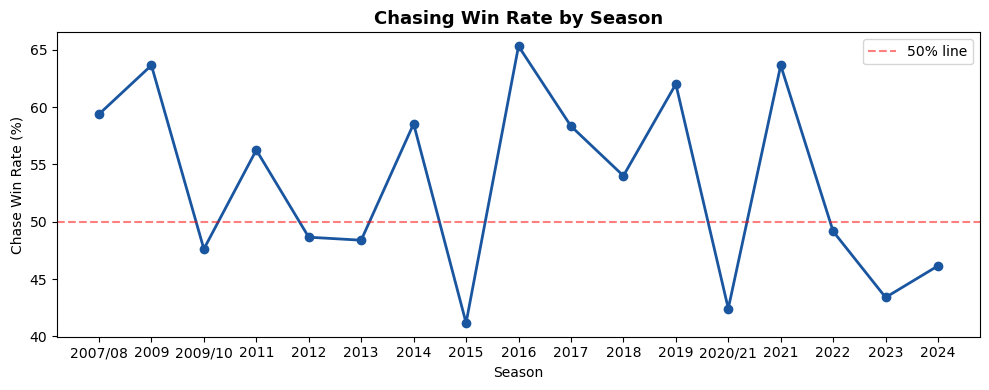

In [7]:
# Did batting first or chasing win more?
bat_first = matches[matches['toss_decision'] == 'bat'].copy()
field_first = matches[matches['toss_decision'] == 'field'].copy()

bat_first['won'] = bat_first['toss_winner'] == bat_first['winner']
field_first['won'] = field_first['toss_winner'] == field_first['winner']

print(f"Batting first win rate: {bat_first['won'].mean()*100:.1f}%")
print(f"Chasing (field first) win rate: {field_first['won'].mean()*100:.1f}%")

# Season-wise trend — has chasing improved over time?
season_chase = matches[matches['toss_decision']=='field'].copy()
season_chase['won'] = season_chase['toss_winner'] == season_chase['winner']
season_trend = season_chase.groupby('season')['won'].mean() * 100

plt.figure(figsize=(10,4))
plt.plot(season_trend.index, season_trend.values,
         marker='o', color='#1A56A0', linewidth=2)
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% line')
plt.title('Chasing Win Rate by Season', fontweight='bold', fontsize=13)
plt.ylabel('Chase Win Rate (%)')
plt.xlabel('Season')
plt.legend()
plt.tight_layout()
plt.show()

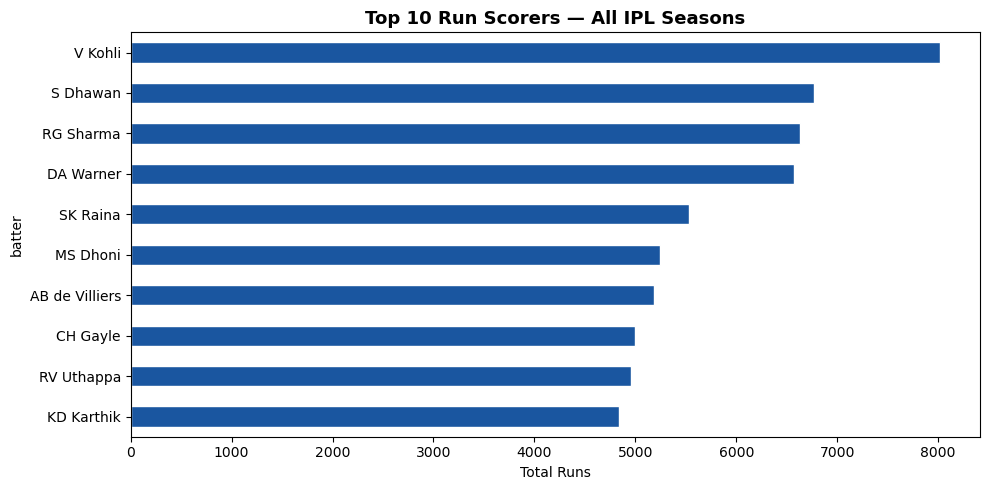

Strike rates of top 10 batter:
batter
AB de Villiers    148.6
CH Gayle          142.1
DA Warner         135.4
MS Dhoni          132.8
SK Raina          132.5
KD Karthik        131.4
V Kohli           128.5
RG Sharma         127.9
RV Uthappa        126.2
S Dhawan          123.5
dtype: float64


In [11]:
# Top 10 run scorers all time
# Use 'batter' for the player name and 'batsman_runs' for their score
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_batsmen.plot(kind='barh', color='#1A56A0', edgecolor='white')
plt.title('Top 10 Run Scorers — All IPL Seasons', fontweight='bold', fontsize=13)
plt.xlabel('Total Runs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Calculate Strike Rates for these 10 players
top_names = top_batsmen.index.tolist()
sr = deliveries[deliveries['batter'].isin(top_names)].groupby('batter').apply(
    lambda x: (x['batsman_runs'].sum() / len(x) * 100)
).sort_values(ascending=False)
print("Strike rates of top 10 batter:")
print(sr.round(1))

Top 10 wicket takers:
bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
SP Narine     180
R Ashwin      180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
Name: dismissal_kind, dtype: int64


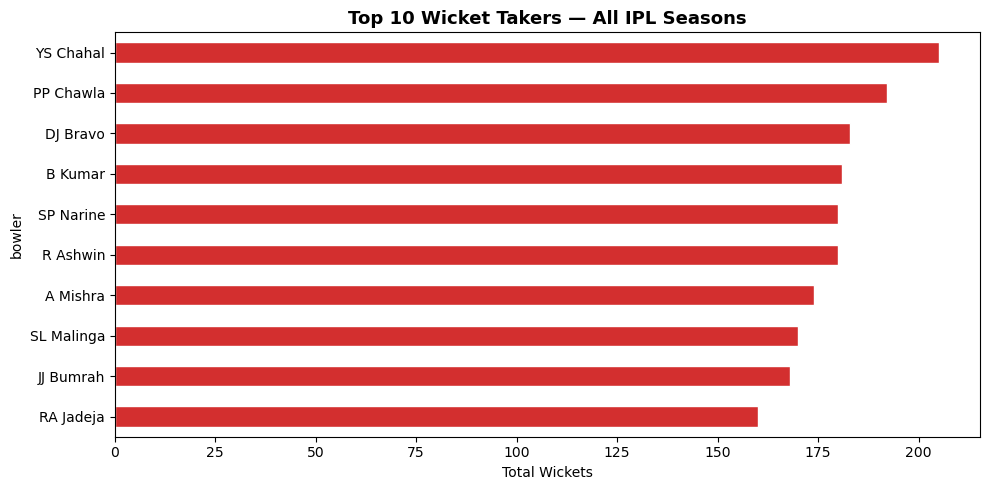

In [12]:
# Filter actual wickets (not run outs)
wickets = deliveries[deliveries['dismissal_kind'].notna() &
                     ~deliveries['dismissal_kind'].isin(['run out','retired hurt','obstructing the field'])]

top_bowlers = wickets.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)
print("Top 10 wicket takers:")
print(top_bowlers)

plt.figure(figsize=(10,5))
top_bowlers.plot(kind='barh', color='#D32F2F', edgecolor='white')
plt.title('Top 10 Wicket Takers — All IPL Seasons', fontweight='bold', fontsize=13)
plt.xlabel('Total Wickets')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

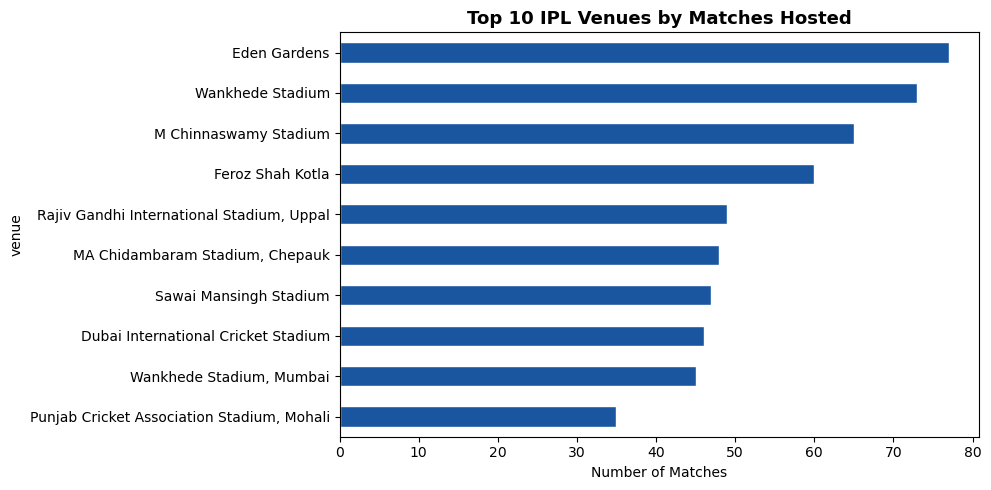

Bat first win % by venue:
venue
MA Chidambaram Stadium, Chepauk               64.6
Dubai International Cricket Stadium           50.0
Wankhede Stadium                              49.3
Feroz Shah Kotla                              45.0
M Chinnaswamy Stadium                         43.1
Punjab Cricket Association Stadium, Mohali    42.9
Wankhede Stadium, Mumbai                      40.0
Eden Gardens                                  39.0
Rajiv Gandhi International Stadium, Uppal     38.8
Sawai Mansingh Stadium                        31.9
Name: bat_first_won, dtype: float64


In [13]:
# Top 10 venues by number of matches
top_venues = matches['venue'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_venues.plot(kind='barh', color='#1A56A0', edgecolor='white')
plt.title('Top 10 IPL Venues by Matches Hosted', fontweight='bold', fontsize=13)
plt.xlabel('Number of Matches')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Bat first win % by top venue
venue_bat = matches[matches['venue'].isin(top_venues.index)].copy()
venue_bat['bat_first_won'] = (
    (venue_bat['toss_decision']=='bat') &
    (venue_bat['toss_winner']==venue_bat['winner']) |
    (venue_bat['toss_decision']=='field') &
    (venue_bat['toss_winner']!=venue_bat['winner'])
)
venue_win = venue_bat.groupby('venue')['bat_first_won'].mean()*100
print("Bat first win % by venue:")
print(venue_win.sort_values(ascending=False).round(1))

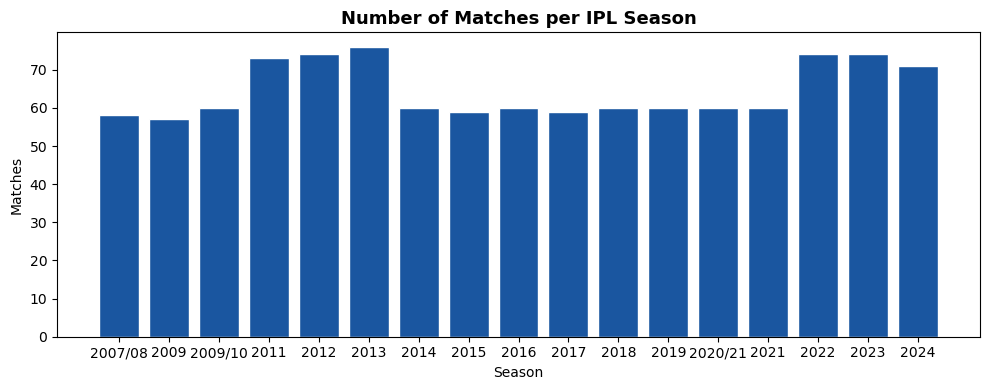

Average runs per match per season:
season
2007/08    309.0
2009       287.0
2009/10    315.0
2011       290.0
2012       303.0
2013       297.0
2014       316.0
2015       311.0
2016       314.0
2017       318.0
2018       332.0
2019       324.0
2020/21    324.0
2021       311.0
2022       330.0
2023       347.0
2024       366.0
dtype: float64


In [14]:
# Matches per season
season_matches = matches.groupby('season').size()

plt.figure(figsize=(10,4))
plt.bar(season_matches.index, season_matches.values, color='#1A56A0', edgecolor='white')
plt.title('Number of Matches per IPL Season', fontweight='bold', fontsize=13)
plt.xlabel('Season')
plt.ylabel('Matches')
plt.tight_layout()
plt.show()

# Average runs per match per season
season_runs = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')
avg_runs = season_runs.groupby('season')['total_runs'].sum() / season_matches
print("Average runs per match per season:")
print(avg_runs.round(0))